# Disciplina: Ciência de Dados (DCA-0131)
Prof. Luiz Affonso Guedes

### Departamento de Engenharia de Computação e Automação - DCA

UFRN - 2025

*OBS: Favor fazer cópia do notebook antes de alterá-lo.

# AULA 16 - Aprendizagem Não Supervisionada com o Pacote Sklearn

##Assunto: Algoritmos de Agrupamento de Dados

### Objetivos - Apresentar os algoritmos de agrupamento de dados K-Means e Hierárquico com o uso do pacote SKLEARN

Prof. Luiz Affonso Guedes

PPGEEC - UFRN
2021-2



### Conteúdo:
- Exemplos de datasets
- Aspectos de análise preliminar de dados
- Algoritmos de Agrupamento Off-line
  - Algoritmo hierárquico aglomerativo
  - Algoritmo K-means
- Métricas de Avaliação de Desempenho de Algoritmos de Agrupamento

### Referências:
- Jake VanderPlas, Python Data Science Handbook - Essential Tools for Working with Data , O’Reilly , 2017.
- Andreas C. Müller and Sarah Guido, Introduction to Machine Learning with Python, O’Reilly , 2017.
- https://scikit-learn.org/stable/modules/clustering.html
- https://towardsdatascience.com/the-5-clustering-algorithms-data-scientists-need-to-know-a36d136ef68



## 1. Intodução
 Carregamento de pacotes auxiliares e algumas base de dados

In [ ]:
# Importação de Pacotes

# Pacote scikitlearn (classe datasets)
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1.1. Dataset Iris do Seaborn

In [ ]:
import seaborn as sns
iris = sns.load_dataset('iris')    # dataset Iris do pacote seaborn
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


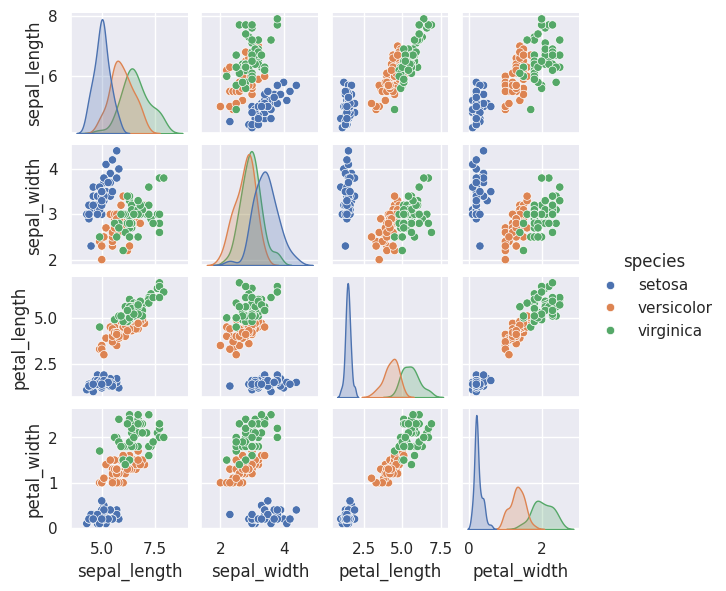

In [ ]:
sns.set()
sns.pairplot(iris, hue='species', size=1.5)

In [ ]:
# Obtenção da Matriz de características (features)

X_iris = iris.drop('species', axis=1)
X_iris.shape

(150, 4)

In [ ]:
X_iris.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# Obtenção do vetor de objetivos (target)
# Para agrupamento não se utiliza o vetor objetivo (target)
y_iris = iris['species']
y_iris.shape

(150,)

In [ ]:
type(X_iris)

pandas.core.frame.DataFrame

<Axes: >

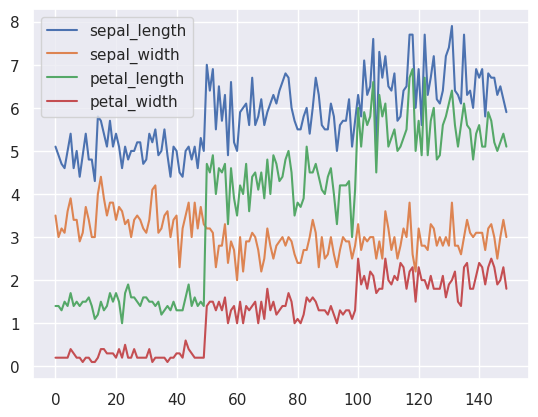

In [ ]:
X_iris.plot()

### 1.2. Dataset Iris do Pacote Sklearn


In [ ]:
# Exemplo de verificação do dataset Iris do pacote Scikit-learn

# Pacote scikitlearn (classe datasets)
from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
iris = datasets.load_iris()   # Dataset Iris do Pacote Sklearn
print(type(iris))

print(iris.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [ ]:
# Verificação dos tipos dos dados do dataset Iris

print(type(iris.data))
print(type(iris.target))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
iris.data.shape

(150, 4)

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
iris.data[0:5,:]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

### 1.3. Dataset do dataset Números do Pacote Sklearn

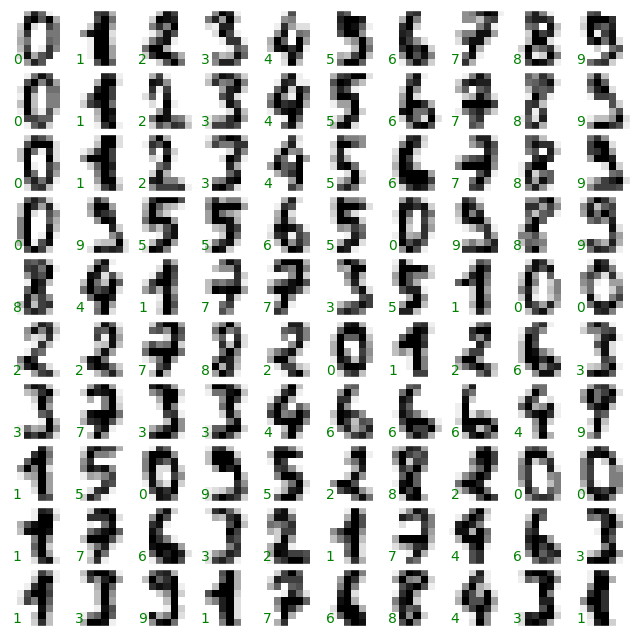

In [ ]:
# Exemplo do dataset números

from sklearn.datasets import load_digits
digits = load_digits()
digits.images.shape

fig, axes = plt.subplots(10, 10, figsize=(8, 8), subplot_kw={'xticks':[], 'yticks':[]}, gridspec_kw=dict(hspace=0.1, wspace=0.1))
for i, ax in enumerate(axes.flat):
  ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
  ax.text(0.05, 0.05, str(digits.target[i]),transform=ax.transAxes, color='green')

In [ ]:
X = digits.data
X.shape

(1797, 64)

In [ ]:
y = digits.target
y.shape

(1797,)

### 1.4. Dataset do make_blobs do Sklearn

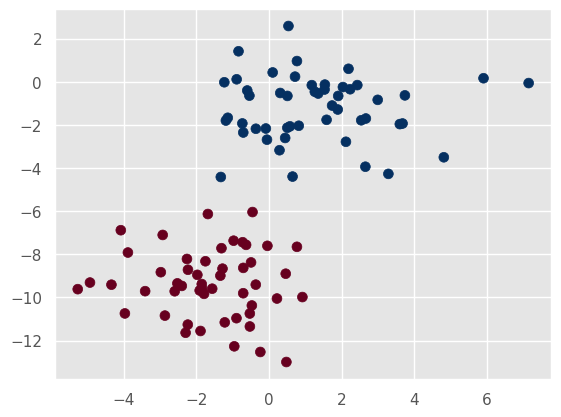

In [ ]:
# Exemplo com 02 clusters

from sklearn.datasets import make_blobs
X, y = make_blobs(100, 2, centers=2, random_state=2, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='RdBu');

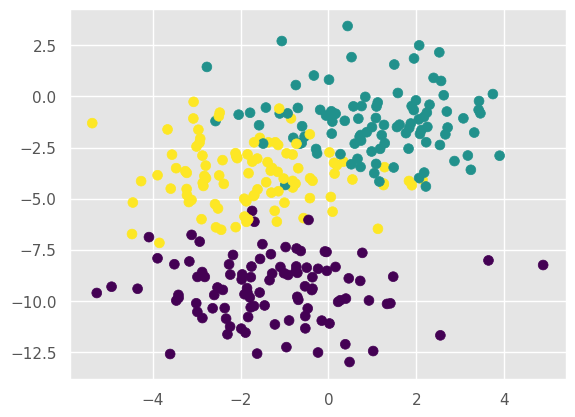

In [ ]:
# Exemplo com 03 clusters

X3, y3 = make_blobs(300, 2, centers=3, random_state=2, cluster_std=1.5)
plt.scatter(X3[:, 0], X3[:, 1], c=y3, s=50, cmap='viridis');

## 2. Procedimento de Uso do modelos Não-Supervisionados com o Pacote Sklearn-Python

Em termos do uso do pacote Sklearn, utiliza-se o seguinte procedimento:
  - Importação da classe do modelo que se deseja utilizar.
  - Instanciar um objeto do modelo selecionado.
  - Treinar o modelo instanciado para um determinado conjunto de de dados.
  - Testar a eficiência do modelo treinado.

### 2.1. Algoritmo de Agrupamento de Dados Hierárquico

- Abordagem aglomerativa

EXPLICAR O ALGORITMO !!!

In [ ]:
# importação de pacotes
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


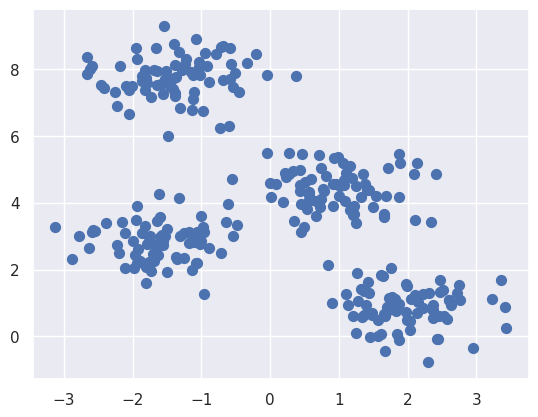

In [ ]:
# Importação dos dados de teste - dataset Bolhas

from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [ ]:
# Aplicação do algoritmo de agrupamento - hierárquico aglomerativo

# Etapas do treinamento não-supervisionado - clusterização

from sklearn.cluster import AgglomerativeClustering              # 1. Importação da classe do modelo a ser utilizado

hierarquico = AgglomerativeClustering(n_clusters = 4)             # 2. Criação do objeto do modelo desejado

y = hierarquico.fit_predict(X)                                    # 3. Ajuste do modelo, com o dado de treino

#y_h = hierarquico.predict(X)                                     # 4. Predição dos grupos feito pelo modelo treinado para um deternimado conjunto de dados


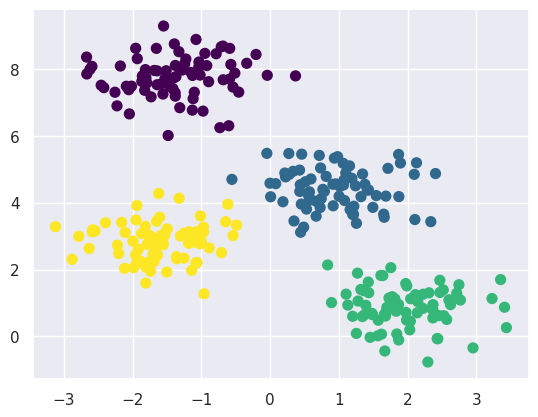

In [ ]:
# Visualização dos resultados

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')

Text(0, 0.5, 'Feature 1')

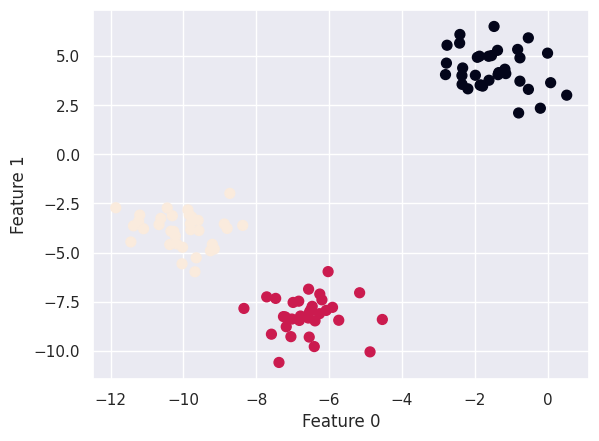

In [ ]:
# Exemplo - Algoritmo hierárquico aglomerativo
# Utilizando o dataset bolhas com três grupos

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

X, y = make_blobs(random_state=1)
agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(X)
#plt.scatter(X[:, 0], X[:, 1], s=50)
plt.scatter(X[:, 0], X[:, 1], c=assignment, s=50)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

In [ ]:
# Hiperparâmetros do modelo Hierárquico Aglomerativo
agg

AgglomerativeClustering(n_clusters=3)

In [ ]:
# Segundo Exemplo de aplicação do algoritmo hierárquico aglomerativo
# Geração dos dados - com três grupos

import numpy as np
import matplotlib.pyplot as plt

MAXN1 = 500
MAXN2 = 400
MAXN3 = 300
X1 = np.concatenate([2.25 * np.random.randn(MAXN1, 2),4 + 1.7*np.random.randn(MAXN2, 2)])
X1 = np.concatenate([X1, [8, 3] + 1.9*np.random.randn(MAXN3, 2)])
y1 = np.concatenate([ np.ones((MAXN1, 1)),2 * np.ones((MAXN2, 1))])
y1 = np.concatenate([y1, 3 * np.ones((MAXN3, 1))]).ravel()
y1 = np.int_(y1)
labels_y1 = ['+', '*', 'o']
colors = ['r', 'g', 'b']

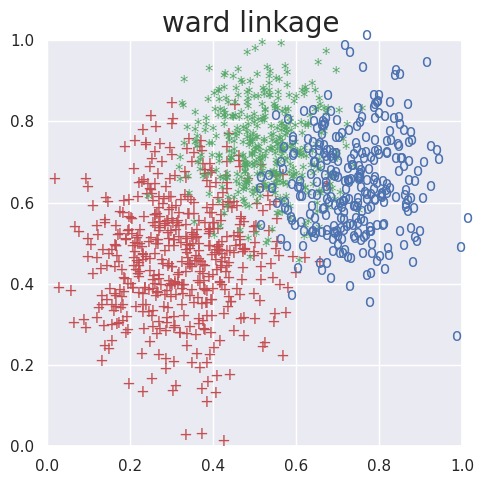

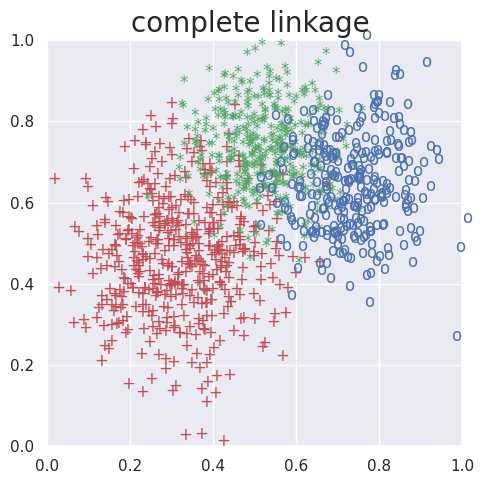

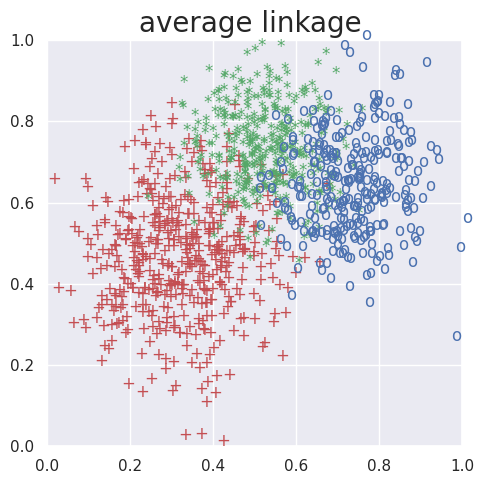

In [ ]:
# Uso do algoritmo hierárquico aglomerativo - exemplo com influência do parâmetro linkage

from sklearn.cluster import AgglomerativeClustering

for linkage in ('ward', 'complete', 'average'):
  clustering = AgglomerativeClustering(linkage = linkage,n_clusters =3)
  clustering.fit(X1)
  x_min , x_max = np.min (X1, axis = 0) , np.max (X1,axis = 0)
  X1 = (X1 - x_min ) / ( x_max - x_min )
  plt.figure ( figsize =(5 , 5))
  for i in range (X1.shape [0]) :
    plt.text(X1[i, 0], X1[i, 1], labels_y1[y1[i]-1], color = colors[y1[i]-1])
  plt.title(linkage + " linkage ", size = 20)
  plt.tight_layout()
plt.show()

Text(0, 0.5, 'Distâcia dos Clusters')

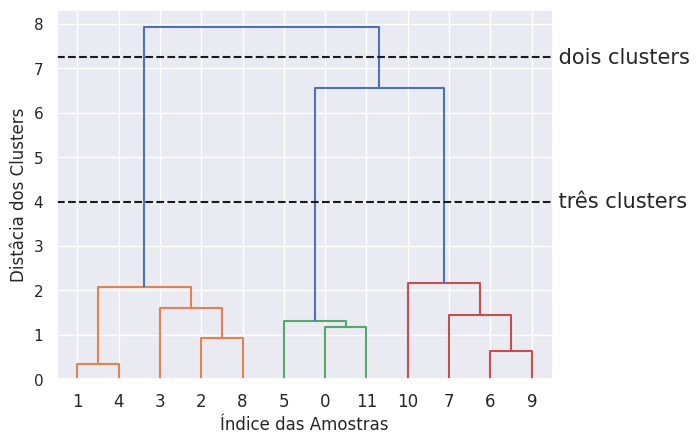

In [ ]:
# Exemplo com plot do Dendrograma

# Importação dos funções dendrogram e ward clustering do pacote SciPy

from scipy.cluster.hierarchy import dendrogram, ward

X, y = make_blobs(random_state=0, n_samples=12) # geração de 12 amostras


# Aplique agrupamento ward à matriz de dados X
# A função SciPy ward retorna uma matriz que especifica as distâncias entre as amostras
# Associar ao executar o algoritmo de agrupamento hierárquico aglomerativo

linkage_array = ward(X)

# Agora, plotamos o dendograma para o linkage_array, que contém as distâncias entre os clusters

dendrogram(linkage_array)

# Marque os cortes na árvore que significam dois ou três grupos

ax = plt.gca()
bounds = ax.get_xbound()
ax.plot(bounds, [7.25, 7.25], '--', c='k')
ax.plot(bounds, [4, 4], '--', c='k')
ax.text(bounds[1], 7.25, ' dois clusters', va='center', fontdict={'size': 15})
ax.text(bounds[1], 4, ' três clusters', va='center', fontdict={'size': 15})
plt.xlabel("Índice das Amostras")
plt.ylabel("Distâcia dos Clusters")

In [1]:
# Dendrograma em Plotly

import plotly.figure_factory as ff
import numpy as np
np.random.seed(1)

X = np.random.rand(15, 12) # 15 samples, with 12 dimensions each
fig = ff.create_dendrogram(X)
fig.update_layout(width=800, height=500)
fig.show()

In [ ]:
# Exercício com o dataset Iris
# Implemente a solução com agrupamento hieráquico aglomerativo
# Teste os diversos valores do parâmetro linkage
# Analise o desempenho do algoritmo - acurácia
# Apresente a visualização da solução


In [ ]:
# Exercício com o dataset Número
# Implemente a solução com agrupamento hieráquico aglomerativo
# Teste os diversos valores do parâmetro linkage
# Analise o desempenho do algoritmo - acurácia
# Apresente a visualização da solução


### 2.2. Algoritmo de Agrupamento de Dados K-Means
O algoritmo k-means baseado em distância (euclidiana), que assume que há k grupos (clusters, agromerações), procura por um número predeterminado de clusters dados multidimensionais não rotulados.
Então, assume duas suposições básicas:
  - O “centro do cluster” é a média aritmética de todos os pontos pertencentes ao cluster.
  - Cada ponto está mais próximo de seu próprio centro de cluster do que dos centros dos outros cluster.


 EXPLICAR O ALGORITMO !!!


In [ ]:
# importação de pacotes
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()


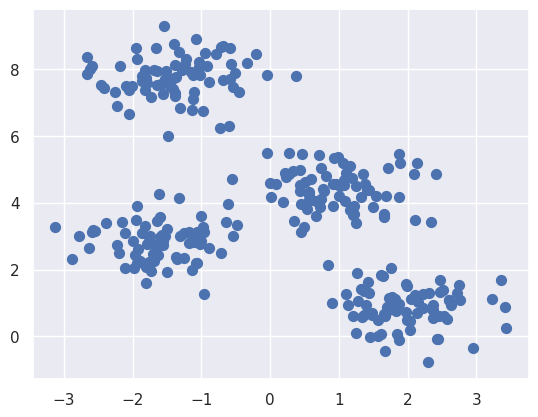

In [ ]:
# Importação dos dados de teste - dataset Bolhas

from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [ ]:
# Etapas do treiamento não supervisionado - agrupamento de dados / clusterização
from sklearn.cluster import KMeans         # 1. Importação da classe do modelo a ser utilizado

kmeans = KMeans(n_clusters=4)              # 2. Criação do objeto do modelo desejado
y = kmeans.fit(X)                          # 3. Ajuste do modelo, com o dado de treino
y_kmeans = kmeans.predict(X)               # 4. Predição dos grupos feito pelo modelo treinado para um deternimado conjunto de dados

#y_p = kmeans.fit_predict(X)               # 3 + 4. Ajuste e predição do modelo, com o dado de treino

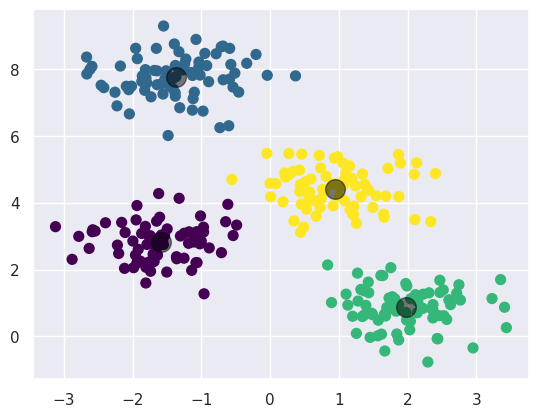

In [ ]:
# Visualização dos resultados

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

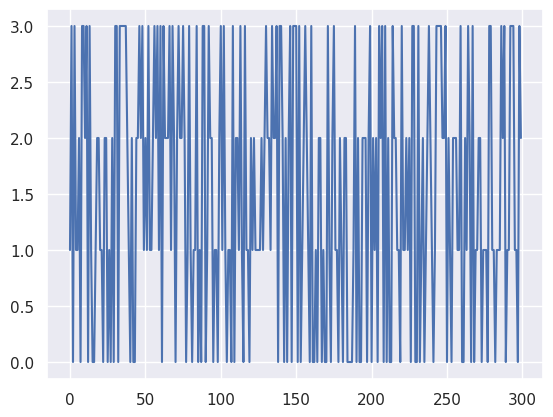

In [ ]:
plt.plot(y_true)

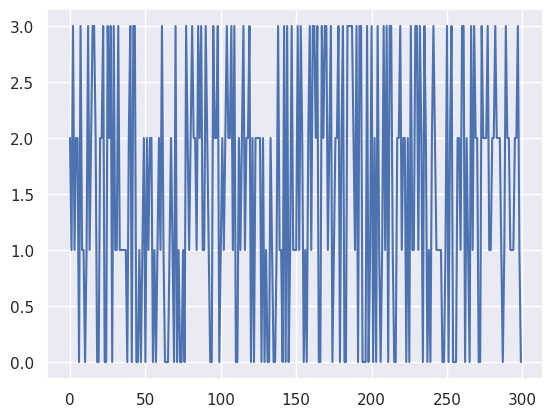

In [ ]:
plt.plot(y_kmeans)

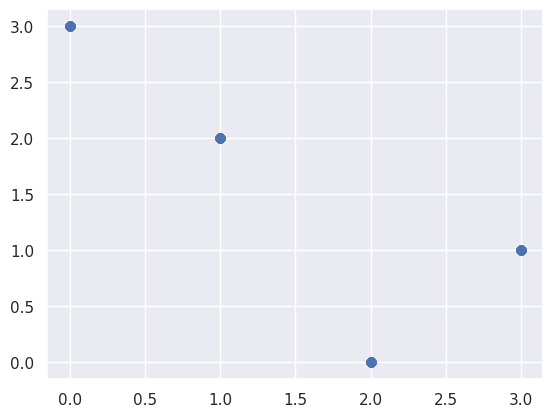

In [ ]:
plt.scatter(y_true,y_kmeans)

In [ ]:
# Hiperparâmetros do modelo Kmeans
kmeans

KMeans(n_clusters=4)

In [ ]:
# Exercício: Re-implemente o exemplo anterior
#  - Utilize outros valores para o número máximo de iterações (max_iter): 1,2,5,7, ...
#  - Como será o desempenho do algoritmo se utilizarmos apenas 3 centros (n_clusters=3)?


In [ ]:
# Exercício - Aplicação com dataset Iris
# Implemente a solução com agrupamento K-Means
# Analise o desempenho do algoritmo - acurácia
# Apresente a visualização da solução



In [ ]:
# Exercício - Aplicação com dataset Números
# Implemente a solução com agrupamento K-Means
# Analise o desempenho do algoritmo - acurácia
# Apresente a visualização da solução


### Limitações do Algoritmos K-Means

O algoritmo K-means é bastante simples e bem eficiente, apresentado uma boa relação custo-benefício, mas possi várias limitações, como:
  - Sensível á iniciação dos centros (utilizar o algoritmo K-Means++).
  - É necessário se assumir a priori o número de grupos.
  - O algoritmo K-Means tem complexidade computacional em função do número de pontos no dataset.
  - O algoritmo trabalha bem para grupos com perfis esfericos.

In [ ]:
# Exemplo de Uso do K-means com visualização - distribuição esférica de dados

from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

def plot_kmeans(kmeans, X, n_clusters=4, rseed=0, ax=None):    # Função para plotar os clusters com círculos
  labels = kmeans.fit_predict(X)
  # plot dos dados de entrada
  ax = ax or plt.gca()
  ax.axis('equal')
  ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)

  # plot da solução do algoritmo/modelo k-means
  centers = kmeans.cluster_centers_
  radii = [cdist(X[labels == i], [center]).max()
    for i, center in enumerate(centers)]
  for c, r in zip(centers, radii):
    ax.add_patch(plt.Circle(c, r, fc='#CCCCCC', lw=3, alpha=0.5, zorder=1))

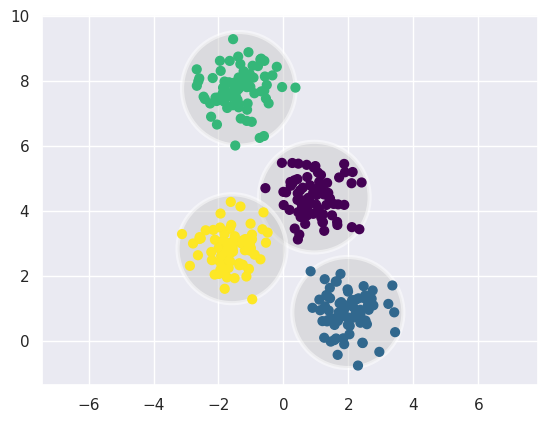

In [ ]:
# Execução das funções KMeans e Plot_kmeans

kmeans = KMeans(n_clusters=4, random_state=0)
plot_kmeans(kmeans, X)

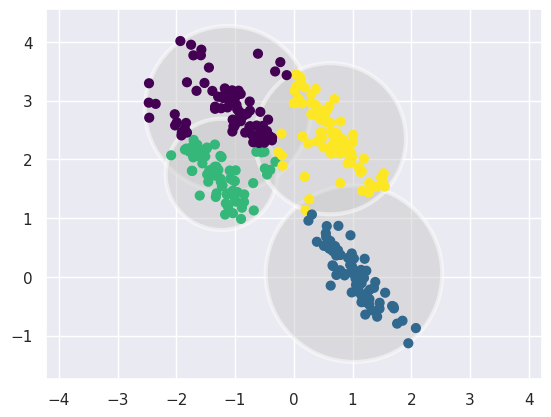

In [ ]:
# Exemplo com distribuição não-esférica dos dados
rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))
kmeans = KMeans(n_clusters=4, random_state=0)
plot_kmeans(kmeans, X_stretched)

In [ ]:
# Exercício:
# - Gere um dataset a partir de uma combinação de 4 distribuições gaussiana bidimensionais
#   - defina os vetor de média, matrizes de covariâncias e quantidade de pontos de cada distribuição
# - Utilize o algoritmo KMeans para fazer o agrupamento dos dados
# - Mostre o desempenho do algoritmo (acurácia e visualização)
# - Analise o desempenho quando os grupos estão próximos e perfis alongados

# Impementação da solução



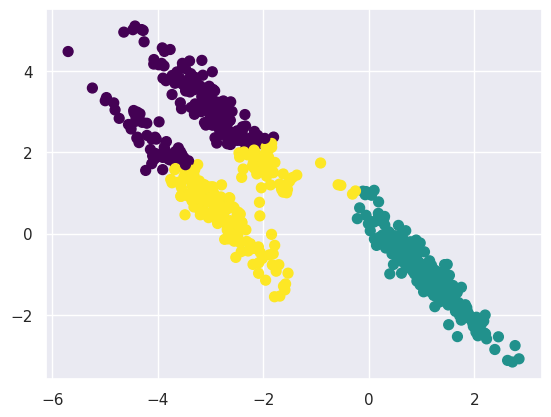

In [ ]:
# Exemplo uso do K-Means em dados com grupos não esféricos  - clusters elípticos

from sklearn.cluster import KMeans                             # Importação da classe do modelo a ser utilizado
from sklearn.datasets import make_blobs                        # Carregamento do Dataset
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()

n_samples = 600
random_state = 170

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X1 = np.dot(X, transformation)

kmeans = KMeans(3, random_state=0).fit(X1)                         # Treinamento do modelo

labels = kmeans.predict(X1)

plt.scatter(X1[:, 0], X1[:, 1], c=labels, s=50, cmap='viridis');


In [ ]:
# Exercício
# Realize o agrupamento do dataset do exemplo anterior com o algoritmo Hierárquico Aglomerativo



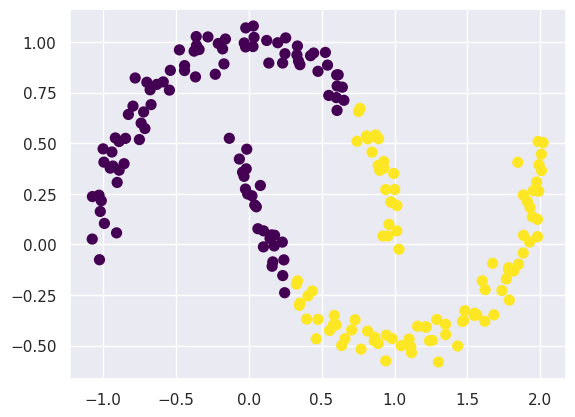

In [ ]:
# Exemplo uso do K-Means em dados com grupos não esféricos

from sklearn.cluster import KMeans                               # Importação da classe do modelo a ser utilizado
from sklearn.datasets import make_moons                          # Carregamento do Dataset
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()

n_samples = 200

X, y = make_moons(n_samples=200, noise=.05, random_state=0)

kmeans = KMeans(2, random_state=0).fit(X)                         # Treinamento do modelo

labels = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');


In [ ]:
# Exercício
# Realize o agrupamento do dataset do exemplo anterior com o algoritmo Hierárquico Aglomerativo

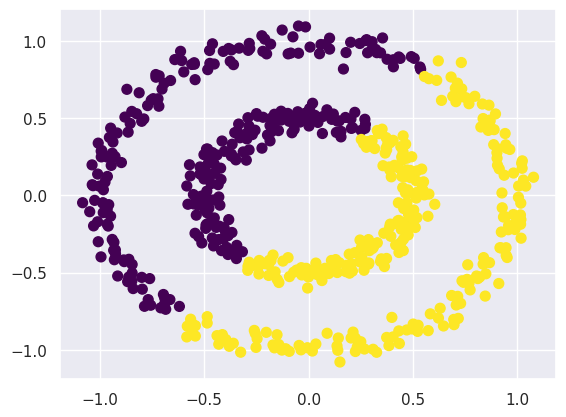

In [ ]:
# Exemplo uso do K-Means em dados com grupos não esféricos

from sklearn.cluster import KMeans                               # Importação da classe do modelo a ser utilizado
from sklearn.datasets import make_circles                        # Carregamento do Dataset
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()

n_samples = 600
X, y = make_circles(n_samples=n_samples, factor=.5, noise=.05)

kmeans = KMeans(2, random_state=0).fit(X)                         # Treinamento do modelo

labels = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [ ]:
# Exercício
# Realize o agrupamento do dataset do exemplo anterior com o algoritmo Hierárquico Aglomerativo



## 3. Métricas de Avaliação de Desempenho de Algoritmos de Agrupamento de Dados
- Métrica com conhecimento *a priori* dos grupos
  - **ARI**: Adjusted Rand index
    - Dado o conhecimento das atribuições da classe de verdade do solo *labels_true* e de nossas atribuições do algoritmo de agrupamento das mesmas amostras *labels_pred*, esse índice é uma função que mede a semelhança das duas atribuições, ignorando permutações e com a normalização do acaso.
  - **MIS**: Mutual Information based scores
      - Dado o conhecimento das atribuições da classe de verdade básica *labels_true* e das atribuições do nosso algoritmo de agrupamento das mesmas amostras *labels_pred*, as **Informações Mútuas** são uma função que mede a concordância das duas atribuições, ignorando as permutações. Estão disponíveis duas versões normalizadas diferentes dessa medida, Informações Mútuas Normalizadas (NMI) e Informações Mútuas Ajustadas (AMI). A MNI é freqüentemente usada na literatura, enquanto a IAM foi proposta mais recentemente e é normalizada contra o acaso.
  - **Homogeneity** (homogeneidade): cada cluster contém apenas membros de uma única classe.
  - **Completeness** (integridade): todos os membros de uma determinada classe são atribuídos ao mesmo cluster.
- Métricas sem conhecimento *a priori* dos grupos
  - ** Silhouette Coefficient**: uma pontuação mais alta deste coeficiente indica que o algoritmo definiu melhor os clusters.
  - Definição formal do coeficiente S
    $$ S = (b-a)/max(a,b)$$
    $a$: A distância média entre uma amostra e todos os outros pontos da mesma classe.
    
    $b$: a distância média entre uma amostra e todos os outros pontos no próximo cluster mais próximo.



In [ ]:
# Exemplo de uso das métricas de avaliação dos algoritmos de agrupamento com conhecimento a priori dos grupos

from sklearn import metrics

labels_true = [0, 0, 0, 1, 1, 1]
labels_pred = [0, 0, 1, 1, 2, 2]
labels_pred2 = [1, 1, 0, 0, 3, 3]

print("Métrica ARI: " , metrics.adjusted_rand_score(labels_true, labels_pred))
print("Métrica ARI: " , metrics.adjusted_rand_score(labels_true, labels_pred2), " (com permutação dos rótulos)")
print("Métrica ARI: " , metrics.adjusted_rand_score(labels_pred, labels_true)," (é simétrica)")
print("Métrica ARI: " , metrics.adjusted_rand_score(labels_true, labels_true)," (grupos iguais)")
print()
print("Métrica MIS: " , metrics.adjusted_mutual_info_score(labels_true, labels_pred))
print("Métrica MIS: " , metrics.adjusted_mutual_info_score(labels_true, labels_pred2), " (com permutação dos rótulos)")
print("Métrica MIS: " , metrics.adjusted_mutual_info_score(labels_pred, labels_true)," (é simétrica)")
print("Métrica MIS: " , metrics.adjusted_mutual_info_score(labels_true, labels_true)," (grupos iguais)")
print()



print(metrics.homogeneity_score(labels_true, labels_pred))
print("Métrica Homogeneity: " , metrics.homogeneity_score(labels_true, labels_pred))
print("Métrica Homogeneity: " , metrics.homogeneity_score(labels_true, labels_pred2), " (com permutação dos rótulos)")
print("Métrica Homogeneity: " , metrics.homogeneity_score(labels_pred, labels_true)," (não é simétrica)")
print("Métrica Homogeneity: " , metrics.homogeneity_score(labels_true, labels_true)," (grupos iguais)")
print()
print(metrics.homogeneity_score(labels_true, labels_pred))
print("Métrica Completeness: " , metrics.completeness_score(labels_true, labels_pred))
print("Métrica Completeness: " , metrics.completeness_score(labels_true, labels_pred2), " (com permutação dos rótulos)")
print("Métrica Completeness: " , metrics.completeness_score(labels_pred, labels_true)," (não é simétrica)")
print("Métrica Completeness: " , metrics.completeness_score(labels_true, labels_true)," (grupos iguais)")
print()
print("As métricas Homogeneity e Completeness são anti-simétricas complementares --> H(a,b)==C(b,a): " , metrics.completeness_score(labels_pred, labels_true) == metrics.homogeneity_score(labels_true, labels_pred))





Métrica ARI:  0.24242424242424243
Métrica ARI:  0.24242424242424243  (com permutação dos rótulos)
Métrica ARI:  0.24242424242424243  (é simétrica)
Métrica ARI:  1.0  (grupos iguais)

Métrica MIS:  0.2987924581708901
Métrica MIS:  0.2987924581708901  (com permutação dos rótulos)
Métrica MIS:  0.2987924581708903  (é simétrica)
Métrica MIS:  1.0  (grupos iguais)

0.6666666666666669
Métrica Homogeneity:  0.6666666666666669
Métrica Homogeneity:  0.6666666666666669  (com permutação dos rótulos)
Métrica Homogeneity:  0.420619835714305  (não é simétrica)
Métrica Homogeneity:  1.0  (grupos iguais)

0.6666666666666669
Métrica Completeness:  0.420619835714305
Métrica Completeness:  0.420619835714305  (com permutação dos rótulos)
Métrica Completeness:  0.6666666666666669  (não é simétrica)
Métrica Completeness:  1.0  (grupos iguais)

As métricas Homogeneity e Completeness são anti-simétricas complementares --> H(a,b)==C(b,a):  True


In [ ]:
# Exemplo de uso do Coeficiente com dataset Iris e algoritmo K-Means
from sklearn import metrics
from sklearn.metrics import pairwise_distances
from sklearn import datasets

X, y = datasets.load_iris(return_X_y=True)

import numpy as np
from sklearn.cluster import KMeans

kmeans_model = KMeans(n_clusters=3, random_state=1).fit(X)
labels = kmeans_model.labels_
metrics.silhouette_score(X, labels, metric='euclidean')

np.float64(0.551191604619592)

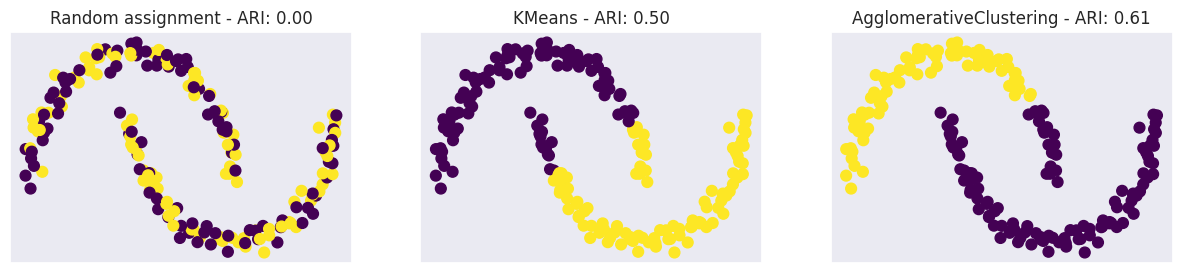

In [ ]:
# Exemplo de avaliação do desempenho dos algoritmos de agrupamento com a métrica ARI

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

from sklearn.datasets import make_moons


X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# reescalonamento dos dados com média zero e variância 1
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 3), subplot_kw={'xticks': (), 'yticks': ()})


# Lista dos algoritmos utilizados
algorithms = [KMeans(n_clusters=2), AgglomerativeClustering(n_clusters=2)]


# criação e atribuição randômica das amostras aos clusters
random_state = np.random.RandomState(seed=0)
random_clusters = random_state.randint(low=0, high=2, size=len(X))


# plot do agrupamento randômico
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=random_clusters, cmap='viridis', s=60)
axes[0].set_title("Random assignment - ARI: {:.2f}".format( adjusted_rand_score(y, random_clusters)))

# plot dos agrupamentos pelos algoritmos: K-means e Hierárquico Aglomerativo
for ax, algorithm in zip(axes[1:], algorithms):
  clusters = algorithm.fit_predict(X_scaled)
  ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', s=60)
  ax.set_title("{} - ARI: {:.2f}".format(algorithm.__class__.__name__, adjusted_rand_score(y, clusters)))



In [ ]:
# Comparação entre medida de Acurácia e medida ARI

from sklearn.metrics import accuracy_score

# Dois Agrupamentos
clusters1 = [0, 0, 1, 1, 0]
clusters2 = [1, 1, 0, 0, 1]

# A acurácia é ZERO quando não há nenhum acerto na atribuição dos grupos
print("Accuracy: {:.2f}".format(accuracy_score(clusters1, clusters2)))

# No caso houve 100% de acerto, porém com rotulação trocada
print("ARI: {:.2f}".format(adjusted_rand_score(clusters1, clusters2)))

Accuracy: 0.00
ARI: 1.00


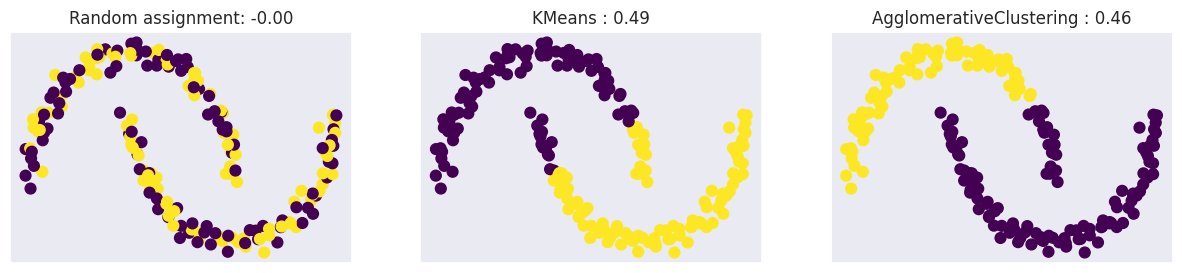

In [ ]:
# Exemplo de avaliação do desempenho dos algoritmos com a métrica Silhouette

import numpy as np
import matplotlib.pyplot as plt


from sklearn.metrics.cluster import silhouette_score
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

# reescalonamento dos dados com média zero e variância 1
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 3), subplot_kw={'xticks': (), 'yticks': ()})


# Lista dos algoritmos utilizados
algorithms = [KMeans(n_clusters=2), AgglomerativeClustering(n_clusters=2)]


# criação e atribuição randômica das amostras aos clusters
random_state = np.random.RandomState(seed=0)
random_clusters = random_state.randint(low=0, high=2, size=len(X))


# plot do agrupamento randômico
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=random_clusters, cmap='viridis', s=60)
axes[0].set_title("Random assignment: {:.2f}".format( silhouette_score(X_scaled, random_clusters)))

# plot dos agrupamentos pelos algoritmos: K-meas, Hierárquico Aglomerativo
for ax, algorithm in zip(axes[1:], algorithms):
  clusters = algorithm.fit_predict(X_scaled)
  ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', s=60)
  ax.set_title("{} : {:.2f}".format(algorithm.__class__.__name__, silhouette_score(X_scaled, clusters)))


In [ ]:
# Exemplo de uso das métricas de avaliação de desempenho de algoritmos de agrupamento
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.metrics.cluster import adjusted_mutual_info_score
from sklearn.metrics.cluster import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics.cluster import silhouette_score

print("Random assignment - ARI: {:.2f}".format( adjusted_rand_score(y, random_clusters)))
print("Random assignment - MIS: {:.2f}".format( adjusted_mutual_info_score(y, random_clusters)))
print("Random assignment - Homogeneity: {:.2f}".format( homogeneity_score(y, random_clusters)))
print("Random assignment - Completeness: {:.2f}".format( completeness_score(y, random_clusters)))
print("Random assignment - Silhouette: {:.2f}".format( silhouette_score(X_scaled, random_clusters)))

print()

for ax, algorithm in zip(axes[1:], algorithms):
  clusters = algorithm.fit_predict(X_scaled)
  print("{} - ARI: {:.2f}".format(algorithm.__class__.__name__, adjusted_rand_score(y, clusters)))
  print("{} - MIS: {:.2f}".format(algorithm.__class__.__name__, adjusted_mutual_info_score(y, clusters)))
  print("{} - Homogeneity: {:.2f}".format(algorithm.__class__.__name__, homogeneity_score(y, clusters)))
  print("{} - Completeness: {:.2f}".format(algorithm.__class__.__name__, completeness_score(y, clusters)))
  print("{} - Silhouette: {:.2f}".format(algorithm.__class__.__name__, silhouette_score(X_scaled, clusters)))
  print()


Random assignment - ARI: 0.00
Random assignment - MIS: 0.00
Random assignment - Homogeneity: 0.01
Random assignment - Completeness: 0.01
Random assignment - Silhouette: -0.00

KMeans - ARI: 0.50
KMeans - MIS: 0.40
KMeans - Homogeneity: 0.40
KMeans - Completeness: 0.40
KMeans - Silhouette: 0.49

AgglomerativeClustering - ARI: 0.61
AgglomerativeClustering - MIS: 0.59
AgglomerativeClustering - Homogeneity: 0.58
AgglomerativeClustering - Completeness: 0.61
AgglomerativeClustering - Silhouette: 0.46

